# [실습] Chronos-2 제로샷 — 평가표에 MASE 적기

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## Chronos-2 제로샷을 인력 예측에 넣을까

<div style="background:#FFFFFF;color:#000000;padding:40px;border-radius:12px;border:1px solid #E6E6E6;border-left:4px solid #051C2C">
<div style="font-size:0.9em;color:#656565">딥러닝 시계열 · 둘째 날</div>
<h1 style="color:#000000;margin:10px 0">Chronos-2 제로샷 — 평가표에 MASE 적기</h1>
<div style="font-size:1.05em;color:#656565">학습하지 않고 부르는 Chronos-2 를 예측 원점 5개에 불러 평가표에 MASE 를 적고, 원점마다 계절 나이브보다 MASE 가 낮은 역 비율을 읽습니다</div>
</div>

**오늘의 질문** 학습 없이 쓰는 Chronos-2 를 다음 주 역별 인력 예측에 넣을까요?
평균 MASE 하나 대신 두 묶음으로 나눠 봅니다. 채점 7일에 평일 공휴일이 없는 원점 2개가 「공휴일 없는 두 주」, 있는 원점 3개가 「공휴일 있는 세 주」입니다. 원점마다 계절 나이브보다 MASE 가 낮은 역 비율도 함께 보고 답합니다.

평가표는 서울 지하철 100개 역(2024년까지 하루 평균 승차가 가장 많은 역 100곳)의 예측을 채점한 표입니다. 채점은 **예측 원점(forecast origin, 채점 첫날)** 5개마다 그날부터 7일씩, 모두 35일 합니다. Chronos-2 제로샷의 MASE 도 이 표에 적습니다. **베이스라인(baseline)** 은 1주일 전 같은 요일 값을 그대로 쓰는 계절 나이브입니다.

1. LMS 에서는 맨 위 설치 셀을 한 번 실행합니다. Chronos-2 가중치 약 480MB 를 내려받아 1～2분 걸립니다. GPU 가 없으면 같은 값이 시간만 더 걸려 나옵니다.
2. 노트북을 내려받아 Colab 이나 내 컴퓨터에서 열었다면 `[채점]` 셀까지 직접 실행합니다. Colab 은 메뉴 **런타임 → 런타임 유형 변경** 에서 GPU(T4)를 먼저 고릅니다. 이어서 맨 위 설치 셀, 그 바로 아래 접힌 `[채점]` 셀 순서로 한 번씩 ▶ 실행합니다.
3. 「오늘의 준비」 셀을 실행해 두고 개념 확인 두 문항부터 풉니다. 데이터 퀴즈는 그 셀의 출력을 읽고 답합니다.

실습이 처음이라면 세 가지를 먼저 봅니다.

- 화면 위쪽 「Claude 도우미」를 설치해 둡니다(온보딩 레슨 참고). 미션의 PROMPT 를 코드로 바꿔 주는 AI 튜터입니다.
- LMS 에서는 코드 영역 머리에 「채점 준비됨」이 표시된 뒤 시작합니다. 미션 셀을 실행했는데 채점 결과가 나오지 않으면 「채점 준비됨」을 누릅니다.
- 막히면 같은 말을 되풀이하지 말고 PROMPT 에 빠진 조건을 하나 더합니다. 그래도 안 되면 요구를 한 덩어리로 다시 적어 새 메시지로 보냅니다.

In [1]:
# 실습 준비 - 패키지 설치·폰트·Chronos-2 내려받기·GPU 확인
# [heavy]
#  Colab 이거나 chronos-forecasting · holidays 가 없으면 2.3.1 · 0.103 을 설치합니다. 이미 깔려 있으면 그 버전을 씁니다.
#  numpy · pandas · pyarrow · torch · matplotlib 은 Colab 기본 버전을 그대로 씁니다.
import os, sys, math, time, subprocess
from importlib.util import find_spec
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB or find_spec("chronos") is None or find_spec("holidays") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "chronos-forecasting==2.3.1", "holidays==0.103"], check=True)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil
if IN_COLAB and shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 그림 전체가 함께 쓰는 색 — 베이스라인=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다
FIGW = FIG_W      # 도우미가 밑줄을 빼고 FIGW 로 옮겨 적는 일이 있어 같은 값을 하나 더 둔다
print("사용 폰트:", FONT, "| 색 팔레트 준비 완료")

# Chronos-2 가중치(약 480MB)를 여기서 한 번 내려받아 둡니다 — 「오늘의 준비」 셀과 미션 준비 셀은 이 사본을 읽습니다.
#  내려받기가 끊기면 10초 쉬고 다시 시도하며, 세 번까지 합니다.
from huggingface_hub import snapshot_download
CHRONOS_ID = "amazon/chronos-2"
for _try in range(1, 4):
    try:
        snapshot_download(CHRONOS_ID, allow_patterns=["config.json", "model.safetensors"])
        print(f"Chronos-2 가중치 준비 완료 — {CHRONOS_ID} ({_try}번째 시도)")
        break
    except Exception as _e:
        print(f"Chronos-2 내려받기 {_try}번째 실패 — {type(_e).__name__}")
        if _try < 3:
            time.sleep(10)
else:   # 받지 못한 채 넘어가면 뒤 셀의 from_pretrained 가 내려받기 오류로 멈춘다 — 여기서 멈춘다
    raise RuntimeError("Chronos-2 가중치를 세 번 모두 받지 못했습니다. LMS 면 이 셀을 다시 실행하고, 그래도 같으면"
                       " 강사에게 알립니다. Colab 이면 메뉴 런타임 → 런타임 다시 시작을 누른 뒤 이 셀부터 다시 실행합니다")

# GPU 확인 — Chronos-2 예측은 여기서 정한 DEVICE 에서 실행됩니다
from importlib.metadata import version
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cuda.matmul.allow_tf32 = False   # fp32 로 계산합니다 — GPU 종류(T4·L4·A100)에 따라 결과가 갈리지 않게
torch.backends.cudnn.allow_tf32 = False
print(f"DEVICE : {DEVICE} | torch {torch.__version__} | chronos-forecasting {version('chronos-forecasting')}")
if DEVICE == "cuda":
    _props = torch.cuda.get_device_properties(0)
    print(f"GPU : {torch.cuda.get_device_name(0)} · 메모리 {_props.total_memory / 1e9:.1f} GB — 준비됐습니다")
else:
    print("GPU 가 연결되지 않았습니다. 메뉴 런타임 → 런타임 유형 변경 → GPU 를 고른 뒤 맨 위 셀부터 다시 실행합니다.")
    print("그대로 두면 같은 코드가 CPU 에서 더 느리게 실행되고, 값은 이 노트북에 적힌 값과 같게 나옵니다.")
if version("chronos-forecasting") != "2.3.1" or not torch.__version__.startswith("2.11."):
    print("참고 — 교안의 수는 torch 2.11.0 · chronos-forecasting 2.3.1 에서 계산했습니다."
          " 지금 버전에서는 소수점 아래 값이 조금 다를 수 있습니다.")

사용 폰트: NanumGothic | 색 팔레트 준비 완료
Fetching 2 files: 100%|██████████| 2/2 [00:04<00:00,  2.20s/it]
Chronos-2 가중치 준비 완료 — amazon/chronos-2 (1번째 시도)
DEVICE : cuda | torch 2.11.0+cu130 | chronos-forecasting 2.3.1
GPU : Tesla T4 · 메모리 15.6 GB — 준비됐습니다


## 서울 지하철 100개 역 준비

자료는 첫날과 같은 **서울 지하철 일별 승차 기록**(서울열린데이터광장 OA-12914, 공공누리 제1유형)입니다. 역은 2015-01-01～2026-06-30 기록이 이어진 역 가운데 2024년까지 평균 승차 상위 100개 역입니다. 「오늘의 준비」 셀이 이 자료로 100개 역 × 4,199일 표를 만듭니다.

| 묶음 | 예측 원점(수요일) | 채점 7일 |
|---|---|---|
| 공휴일 없는 두 주 | 2025-12-10 · 2026-06-24 | 평일 공휴일 없음 |
| 공휴일 있는 세 주 | 2025-08-13 · 2025-10-01 · 2026-02-11 | 평일 공휴일 있음 |

「오늘의 준비」 셀은 Chronos-2 를 원점 넷에만 부릅니다. 표 2·그림 1·표 3 에 쓰는 원점 2026-06-24 와 표 4 에 쓰는 공휴일 있는 세 주입니다. 아래 다섯을 출력하고, Colab 의 CPU 에서도 1분 안쪽입니다.

- 표 1 · 계절 나이브의 예측 원점별 MASE (배)
- 표 2 · 강남역 원점 2026-06-24 Chronos-2 제로샷 예측과 실제 (명)
- 그림 1 · 강남역 원점 전 8주 승차와 Chronos-2 제로샷 7일 예측
- 표 3 · 강남역 컨텍스트 512일의 요일별 평균 승차 (명)
- 표 4 · 공휴일 있는 세 주의 평일, 100개 역 예측 합 ÷ 실제 합 (배)

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 1054.87it/s]
행렬 : 100개 역 x 4,199일 · 2015-01-01 ~ 2026-06-30
Chronos-2 : amazon/chronos-2 · fp32 · DEVICE cuda · 불러오기 1.6초 · 원점 넷 예측 2.5초 · 학습 없음

표 1 · 계절 나이브의 예측 원점별 MASE (배)
예측 원점    2025-08-13  2025-10-01  2025-12-10  2026-02-11  2026-06-24
계절 나이브       1.069       4.388       0.419       2.844       0.471
두 묶음 평균 : 공휴일 없는 두 주 0.445 · 공휴일 있는 세 주 2.767

표 2 · 강남역 원점 2026-06-24 Chronos-2 제로샷 예측과 실제 (명)
           06-24(수) 06-25(목) 06-26(금) 06-27(토) 06-28(일) 06-29(월) 06-30(화)
실제          94,303    94,077    98,456    67,630    40,248    89,909    92,064
0.1 분위수    90,183    90,044    91,775    59,391    31,381    79,432    81,366
0.5 분위수    94,030    94,683    96,552    67,342    39,453    89,875    91,981
0.9 분위수    96,069    96,606    98,878    71,988    44,704    92,958    94,357
표 3 · 강남역 컨텍스트 512일의 요일별 평균 승차 (명)
컨텍스트 2025-01-28 ~ 2026-06-23 (512일, 마지막 날 = 원점 전날)
               월      화      수      목      금      토      일
평균 승차

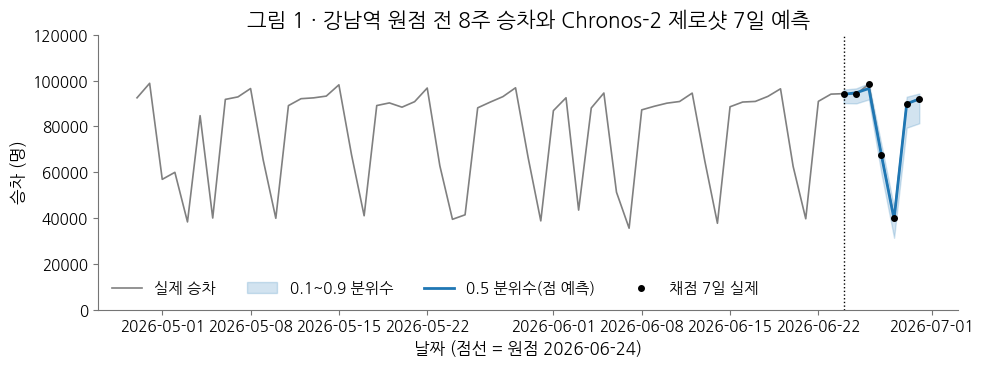

In [2]:
# 오늘의 준비 — 읽고 실행만 합니다
# 서울 지하철 100개 역으로 표 1 · 표 2 · 그림 1 · 표 3 · 표 4 를 만듭니다. Chronos-2 는 원점 넷에 한 번씩 부르고 학습은 하지 않습니다
# Chronos-2 를 불러오다 내려받기 오류(Hugging Face)가 나면 맨 위 설치 셀부터 다시 실행합니다
import os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import holidays

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 첫날과 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]

MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 표 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 표 행의 역 이름

ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]                                       # 공휴일 없는 두 주
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]                           # 공휴일 있는 세 주
H, CTX = 7, 512                               # 채점 7일 · 컨텍스트 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # Chronos-2 가 내는 분위수 아홉 개 (점 예측은 0.5)
SEED = 0                                      # 시드
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 설치 셀과 같은 규칙, 이 셀만 실행해도 정해집니다
torch.backends.cuda.matmul.allow_tf32 = False            # fp32 로 계산합니다


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지의 100개 역(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)   # 원점 전날까지로 계산한 분모
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden)


# 계절 나이브: 원점 전 7일(1주일 전 같은 요일 값)을 그대로 7일 예측으로 씁니다
SN_MASE = {}                                  # 원점 → 계절 나이브의 100개 역 평균 MASE
for _d in ORIGINS:
    _c = origin_ctx(_d)
    SN_MASE[_d] = float(np.mean(np.abs(_c["test"] - MAT[:, _c["o"] - 7:_c["o"]]) / _c["qden"][:, None]))
SN_PLAIN = float(np.mean([SN_MASE[_d] for _d in PLAIN_ORIGINS]))
SN_HOL = float(np.mean([SN_MASE[_d] for _d in HOL_ORIGINS]))

# Chronos-2 를 DEVICE 에 올리고, 원점마다 100개 역의 원점 전날까지 512일을 롱 포맷 표 하나로 넘겨 7일을 한 번에 받습니다
from chronos import BaseChronosPipeline
_t0 = time.perf_counter()
PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
_load_sec = time.perf_counter() - _t0
_n_st, _g = len(STATIONS), STATIONS.index("2호선 강남")
_point, _t1 = {}, time.perf_counter()        # _point: 원점 → 100개 역 x 7일 점 예측("0.5" 열)
for _d in ["2026-06-24"] + HOL_ORIGINS:
    _o = origin_ctx(_d)["o"]
    _long = pd.DataFrame({"item_id": np.repeat(np.arange(_n_st), CTX),           # 역 · 날짜 · 승차 세 열
                          "timestamp": np.tile(DATES[_o - CTX:_o].values, _n_st),
                          "target": MAT[:, _o - CTX:_o].ravel()})
    torch.manual_seed(SEED)
    _fc = PIPE.predict_df(_long, prediction_length=H, quantile_levels=QS, context_length=CTX, freq="D")
    _fc = _fc.sort_values(["item_id", "timestamp"])
    _point[_d] = _fc["0.5"].to_numpy().reshape(_n_st, H)
    if _d == "2026-06-24":
        _gfc = _fc[_fc["item_id"] == _g]
_pred_sec = time.perf_counter() - _t1

# 표 2 · 표 3 의 값: 강남역 원점 2026-06-24
_o = origin_ctx("2026-06-24")["o"]
GN_FC = pd.DataFrame({"actual": MAT[_g, _o:_o + H], "0.1": _gfc["0.1"].to_numpy(),
                      "0.5": _gfc["0.5"].to_numpy(), "0.9": _gfc["0.9"].to_numpy()}, index=DATES[_o:_o + H])
GN_CTX_LAST = DATES[_o - 1]                   # 컨텍스트 마지막 날 = 원점 전날
_ctx = DATES[_o - CTX:_o]
_DOW = ["월", "화", "수", "목", "금", "토", "일"]
GN_DOW = pd.Series(MAT[_g, _o - CTX:_o], index=_ctx).groupby(_ctx.dayofweek).mean()
GN_DOW.index = _DOW

# 표 4 의 값: 공휴일 있는 세 주의 채점 7일 가운데 평일(월~금)을 공휴일 6일과 공휴일 아닌 날 9일로 나눕니다
_kr = holidays.KR(years=[2025, 2026])
_hol6, _wk9 = [], []                          # (원점, 원점부터 며칠째) 목록
for _d in HOL_ORIGINS:
    for _k in range(H):
        _day = DATES[origin_ctx(_d)["o"] + _k]
        if _day.dayofweek < 5:
            (_hol6 if _day.date() in _kr else _wk9).append((_d, _k))
HOL_DAYS = [str(DATES[origin_ctx(_d)["o"] + _k].date()) for _d, _k in _hol6]
_pred_of = {"Chronos-2 제로샷": lambda d: _point[d],
            "계절 나이브": lambda d: MAT[:, origin_ctx(d)["o"] - 7:origin_ctx(d)["o"]]}


def _sum_ratio(pred, days):
    """고른 날들의 100개 역 예측 합 ÷ 실제 합"""
    return float(sum(pred(_d)[:, _k].sum() for _d, _k in days)
                 / sum(origin_ctx(_d)["test"][:, _k].sum() for _d, _k in days))


HOL_RATIO = pd.DataFrame({"hol6": {m: _sum_ratio(f, _hol6) for m, f in _pred_of.items()},
                          "wk9": {m: _sum_ratio(f, _wk9) for m, f in _pred_of.items()}})
HOL_ALLOVER = {m: int(np.all([f(_d)[:, _k] > origin_ctx(_d)["test"][:, _k] for _d, _k in _hol6], axis=0).sum())
               for m, f in _pred_of.items()}   # 평일 공휴일 6일 모두 실제보다 높게 예측한 역 수

# 자료 확인 (출력 없음) — 계절 나이브 다섯 값, 강남 MASE 분모, 컨텍스트 기간, Chronos-2 가 입력을 16일씩 묶는 패치 크기, 표 4
assert MAT.shape == (100, 4199)
assert [round(SN_MASE[_d], 3) for _d in ORIGINS] == [1.069, 4.388, 0.419, 2.844, 0.471]
assert (round(SN_PLAIN, 3), round(SN_HOL, 3)) == (0.445, 2.767)
assert round(float(origin_ctx("2026-06-24")["qden"][_g]), 1) == 7813.8
assert (str(_ctx[0].date()), str(GN_CTX_LAST.date())) == ("2025-01-28", "2026-06-23")
assert PIPE.model.chronos_config.input_patch_size == 16
assert HOL_DAYS == ["2025-08-15", "2025-10-03", "2025-10-06", "2025-10-07", "2026-02-16", "2026-02-17"]
assert abs(HOL_RATIO.loc["Chronos-2 제로샷", "hol6"] - 2.14) < 0.02 and 94 <= HOL_ALLOVER["Chronos-2 제로샷"] <= 98

print(f"행렬 : {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 · {DATES[0].date()} ~ {DATES[-1].date()}")
print(f"Chronos-2 : amazon/chronos-2 · fp32 · DEVICE {DEVICE} · 불러오기 {_load_sec:.1f}초"
      f" · 원점 넷 예측 {_pred_sec:.1f}초 · 학습 없음")
print()
print("표 1 · 계절 나이브의 예측 원점별 MASE (배)")
_tab1 = pd.DataFrame([SN_MASE], index=["계절 나이브"]).round(3)
_tab1.columns.name = "예측 원점"
print(_tab1.to_string())
print(f"두 묶음 평균 : 공휴일 없는 두 주 {SN_PLAIN:.3f} · 공휴일 있는 세 주 {SN_HOL:.3f}")
print()
print("표 2 · 강남역 원점 2026-06-24 Chronos-2 제로샷 예측과 실제 (명)")
_tab2 = GN_FC.T.round().astype(int).map("{:,}".format)
_tab2.index = ["실제", "0.1 분위수", "0.5 분위수", "0.9 분위수"]
_tab2.columns = [f"{_x:%m-%d}({_DOW[_x.dayofweek]})" for _x in GN_FC.index]
print(_tab2.to_string())

_win = slice(_o - 56, _o + H)                 # 원점 전 8주와 채점 7일
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(DATES[_win], MAT[_g, _win], color="gray", lw=1.2, label="실제 승차")
ax.fill_between(GN_FC.index, GN_FC["0.1"], GN_FC["0.9"], color="tab:blue", alpha=0.2, label="0.1~0.9 분위수")
ax.plot(GN_FC.index, GN_FC["0.5"], color="tab:blue", lw=2, label="0.5 분위수(점 예측)")
ax.plot(GN_FC.index, GN_FC["actual"], "o", color="black", ms=4, label="채점 7일 실제")
ax.axvline(DATES[_o], color="black", ls=":", lw=1)
ax.set_ylim(0, 120000)
ax.set_title("그림 1 · 강남역 원점 전 8주 승차와 Chronos-2 제로샷 7일 예측")
ax.set(xlabel="날짜 (점선 = 원점 2026-06-24)", ylabel="승차 (명)")
ax.legend(loc="lower left", ncol=4, frameon=False)
plt.show()

print("표 3 · 강남역 컨텍스트 512일의 요일별 평균 승차 (명)")
print(f"컨텍스트 {_ctx[0].date()} ~ {GN_CTX_LAST.date()} ({CTX}일, 마지막 날 = 원점 전날)")
print(GN_DOW.round().astype(int).map("{:,}".format).to_frame("평균 승차").T.to_string())
print()
print("표 4 · 공휴일 있는 세 주의 평일, 100개 역 예측 합 ÷ 실제 합 (배)")
print("평일 공휴일 6일 : " + " · ".join(HOL_DAYS))
_tab4 = pd.DataFrame({"평일 공휴일 6일": HOL_RATIO["hol6"].map("{:.3f}배".format),
                    "공휴일 아닌 평일 9일": HOL_RATIO["wk9"].map("{:.3f}배".format),
                    "6일 모두 실제보다 높게 예측한 역": pd.Series(HOL_ALLOVER).map("{}개 역".format)})
print(_tab4.to_string())

## 제로샷과 예측 원점 확인

> **[문제] 원점 당일의 열 번호가 o 일 때 MAT[:, o - 512:o] 가 담는 날**
>
> 100개 역 × 날짜 표 MAT 에서 원점 2026-06-24 의 열 번호가 o 라고 합시다.
>
> 1. 원점 당일까지 512일이라, 채점 첫날의 실제값이 입력에 있다
> 2. 원점 전날까지 512일이고, 채점 7일의 값은 입력에 없다
> 3. 이 512일로 가중치를 다시 학습한 뒤 7일을 예측한다

> **[문제] 채점 7일 동안 날마다 실제값을 넣어 다시 예측하면 무엇을 채점하나**
>
> 1. 원점 당일 아침에는 낼 수 없는 예측을 채점해, 운영에서 받을 오차보다 작게 나온다
> 2. 같은 모델에 같은 512일을 넣으니, 7일을 한 번에 예측한 채점과 같은 값이 나온다
> 3. 하루씩 예측하면 오차가 누적돼, 7일을 한 번에 예측한 채점보다 크게 나온다

## 강남역 주말 예측과 공휴일 있는 주의 인력

아래 두 문항은 「오늘의 준비」 셀 출력을 읽고 답합니다. 첫 문항은 표 2 와 표 3 을 함께 봅니다. 표 4 는 평일 공휴일이 있는 주에 이 예측을 인력 계획에 써도 되는지 판단하는 근거입니다.

> **[문제] 강남역 주말 예측이 낮은 까닭**
>
> 「오늘의 준비」 셀을 실행하면 나오는 「표 2 · 강남역 원점 2026-06-24 Chronos-2 제로샷 예측과 실제 (명)」과 「표 3 · 강남역 컨텍스트 512일의 요일별 평균 승차 (명)」을 봅니다. 이 노트북의 Chronos-2 제로샷이 토·일을 낮게 예측한 까닭은?
>
> 1. 입력 512일에 토·일이 낮은 요일 모양이 있어 거기서 읽었다
> 2. 원점마다 강남역 512일로 가중치를 조금 고쳐 요일 모양을 배웠다
> 3. 채점 7일의 실제값이 입력에 있어 주말 값을 미리 보았다

> **[문제] 평일 공휴일이 있는 주의 역별 인력**
>
> 「오늘의 준비」 셀을 실행하면 나오는 「표 4 · 공휴일 있는 세 주의 평일, 100개 역 예측 합 ÷ 실제 합 (배)」를 봅니다. 평일 공휴일이 있는 주의 역별 인력을 Chronos-2 제로샷 예측으로 정해도 될까요?
>
> 1. 정해도 된다. 512일 입력에 지난 설·추석이 있다
> 2. 정해도 된다. 공휴일 아닌 평일 9일의 합이 실제와 거의 같다
> 3. 공휴일 날은 이 예측으로 정하지 않고 공휴일 아닌 날만 쓴다. 평일 공휴일에는 계절 나이브처럼 실제의 약 2배를 예측했다

## 미션 1 — Chronos-2 제로샷의 MASE 와 역별 비교

데이터 퀴즈의 강남역 예측을 100개 역 × 원점 5개로 넓혀 MASE 를 적습니다.

#### 할 일 — 미션 1 (25분)

1. 아래 「미션 1 준비 셀」을 실행합니다(1분 안쪽). 이 셀은 고치지 않습니다.
2. 아래 「만들 것」대로 시킬 일을 「PROMPT 셀」의 `PROMPT = """ """` 따옴표 안에 내 말로 적습니다. 예시 프롬프트도 따옴표 안에 붙여 넣어야 채점됩니다.
3. 셀을 클릭한 채 AI 튜터에게 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶ 합니다. LMS 밖이면 받은 코드를 AI 코드 표시선(`# --- 여기부터 AI 코드 ---`) 아래에 둡니다.
4. 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 3번부터 다시 합니다.

**이 미션의 질문**: 공휴일 없는 두 주에 Chronos-2 제로샷은 역의 몇 % 에서 계절 나이브보다 MASE 가 낮을까요?

**쓸 수 있는 것**: 「미션 1 준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 |
|---|---|
| `MAT` · `DATES` · `STATIONS` · `ORIGINS` · `PLAIN_ORIGINS` · `HOL_ORIGINS` | 100개 역 × 4,199일 승차(명)와 그 날짜·역 이름, 원점 5개와 두 묶음(날짜 문자열) |
| `H` · `CTX` · `QS` · `SEED` · `DEVICE` · `PIPE` | 채점 7일, 컨텍스트 512일, 분위수 아홉 개, 시드 0, 예측을 계산하는 GPU 또는 CPU 와 불러 둔 Chronos-2 |
| `origin_ctx(origin)` | 원점 하나의 사전: 원점의 열 번호 `o`, 원점 전날까지의 승차 `hist`, 채점 7일 실제 `test`(100개 역 × 7일), 역마다 MASE 분모 `qden` |
| `score(y, pred, qden)` | 값 둘을 담은 사전: `"mase"` 100개 역 평균 MASE, `"rmse"` RMSE(명) |
| `mase_by_station(y, pred, qden)` | 역마다 MASE 100개 배열(아래 「만들 것」 2번처럼 역끼리 비교할 때) |
| `SN_ST` | 원점 날짜 → 계절 나이브의 역별 MASE 100개 |
| `COL` · `FIG_W` | 그래프 색 사전과 그림 가로 크기(설치 셀) |

#### 만들 것

굵은 이름은 채점이 찾으니 글자 그대로 쓰고, 셋 모두 「PROMPT 셀」에서 출력합니다.

1. **공휴일 없는 두 주 제로샷 평균 MASE**: 소수 셋째 자리. 원점마다 `"0.5"` 열로 MASE 를 구해 `PLAIN_ORIGINS` 두 원점을 평균합니다
2. **공휴일 없는 두 주에서 계절 나이브보다 MASE 가 낮은 역 비율**: 단위 % · 소수 첫째 자리. 역별 MASE 200개(100개 역 × 원점 2개) 가운데 Chronos-2 쪽이 `SN_ST` 보다 작은 비율입니다
3. **그래프 한 장**: 종류는 자유이고 가로축 「예측 원점」, 세로축 「계절 나이브보다 MASE 가 낮은 역 비율(%)」 이름을 답니다. 권장은 원점 5개의 비율 막대(세로축 0～100)입니다

**통과 기준**: 1·2번 값이 「이름 = 값」 한 행씩 있고 기준 범위 안이며, 그래프에 가로축·세로축 이름이 있으면 통과입니다.

`PIPE.predict_df` 의 두 표는 한 행이 역 하나의 하루입니다.

| 표 | 열 | 2호선 강남의 한 행 |
|---|---|---|
| 입력 표: 원점 하나에 100개 역 × 512일 = 51,200행 | `item_id`(MAT 행 번호) · `timestamp` · `target` | 0 · 2026-06-23 · 94,098명 |
| 출력 표: 원점 하나에 100개 역 × 7일 = 700행, 분위수 아홉 열 | `"0.1"` · `"0.5"` · `"0.9"` 등 | 2026-06-24 에 90,183 · 94,030 · 96,069명(실제 94,303명) |

#### 프롬프트에 넣을 것(힌트)

- **고정할 이름 · 시드 · 기간**: 위 표의 이름과 `PIPE` 를 다시 만들지 말고, 시드 0, 컨텍스트는 원점 전날까지의 512일만 쓰라고 적습니다.
- **역끼리 비교**: 역 이름을 `item_id` 로 두면 정렬·pivot 에서 가나다순으로 섞입니다. 그래서 `item_id` 를 MAT 행 번호 0～99 로 두어 역 순서가 `STATIONS` 와 같게 하고, 역별 MASE 를 `SN_ST` 와 역끼리 비교하라고 적습니다.
- **출력·그래프**: 값 두 개의 이름·자릿수와 막대그래프 요구를 옮깁니다.

<details class="lms-extra"><summary>자세히 — 예시 프롬프트</summary>

위 표의 이름과 PIPE 는 다시 만들지 말고 시드 0 으로 예측해 줘. 원점마다 MAT[:, o - CTX:o] 를 item_id · timestamp · target 롱 포맷 표로 만들어(item_id 는 MAT 행 번호 0～99) predict_df 에 prediction_length=H 로 전달하고, 정렬한 "0.5" 열을 100개 역 × 7일로 바꿔 mase_by_station 으로 역별 MASE 를 구한 뒤 SN_ST 와 역끼리 비교해 줘. 원점마다 컨텍스트 첫날·마지막 날, 두 MASE, 비율을 한 행씩 출력하고 "공휴일 없는 두 주 제로샷 평균 MASE = 값" 과 "공휴일 없는 두 주에서 계절 나이브보다 MASE 가 낮은 역 비율 = 값%" 를 한 행씩 출력해 줘. 원점 5개의 비율을 막대로 그리고 50 에 가로 점선, 가로축 「예측 원점」, 세로축 「계절 나이브보다 MASE 가 낮은 역 비율(%)」 이름을 달아 줘.

</details>

#### 예상 적기

> **[예측] 「만들 것」 2번 값은 공휴일 없는 두 주의 역별 MASE 200개(100개 역 × 원점 2개)로 구합니다. 원점 5개의 역별 MASE 500개(100개 역 × 원점 5개)를 한데 모아 구하면 2번 값과 비교해 어떻게 나올까요?**
>
> 1. 크게 낮아진다. 공휴일 있는 세 주의 역별 MASE 300개가 함께 들어간다
> 2. 거의 같다. 원점마다 역이 100개씩이다
> 3. 더 높아진다. 비교하는 역별 MASE 가 많을수록 비율이 올라간다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

<details class="lms-extra"><summary>배경 — 사전학습 모델</summary>

<img src="https://d2l.ai/_images/nlp-map-pretrain.svg" alt="자연어 처리에서 사전학습 상자가 맨 아래에 있고 그 가중치를 위의 모델 구조 상자와 응용 상자가 가져다 쓰는 구성도" width="980" height="465"/>
<p align="center"><em>▲ 자연어 처리 분야의 구성도. 맨 아래 사전학습 상자가 정한 가중치를 위 응용이 가져다 쓴다. Chronos-2 는 시계열에서 이 맨 아래 상자에 해당한다 (출처: Dive into Deep Learning, d2l.ai)</em></p>

Chronos-2 기술 보고서가 공개된 2025-10-17 전의 원점 둘(2025-08-13 · 2025-10-01)은 채점 7일이 사전학습 자료에 있었는지 확인할 수 없습니다. 그래서 평가표에 그 사실을 함께 적습니다.

</details>

<details class="lms-extra"><summary>자세히 — AI 튜터에 맡길 일과 내가 확인할 일</summary>

AI 튜터는 마지막으로 클릭한 코드 셀에 코드를 넣습니다. 오른쪽은 **틀려도 오류가 나지 않아** 사람이 확인해야 하는 일입니다.

| AI 튜터에 맡길 일 | 내가 확인할 일 |
|---|---|
| 원점마다 롱 포맷 표를 만들어 `predict_df` 부르기 | 컨텍스트의 **마지막 날이 원점 전날**인가 |
| 결과 정렬과 100개 역 × 7일 모양 맞추기 | 점 예측이 **`"0.5"` 열**인가, 예측 날짜가 **원점부터 7일**인가, 100개 역 × 7일의 행 순서가 **MAT 행 순서**인가(첫 행이 2호선 강남인가) |
| 역별 MASE, 계절 나이브보다 MASE 가 낮은 역 비율, 막대그래프 | 역별 MASE 를 **역끼리** 비교했나(평균끼리가 아니다), 비율이 **백분율**인가 |

점 예측을 `"0.5"` 열로 하는 것은 0.5 분위수가 중앙값(가운데 값)이기 때문입니다. 숫자 하나로 예측할 때 절대 오차의 평균은 중앙값에서 가장 작습니다. 첫날 강남역 개천절 주 다섯 날(88.4 · 90.4 · 89.9 · 89.7 · 43.7천 명)을 숫자 하나 c 로 예측할 때도 MAE 가 가장 작은 c 는 가운데 값 89.7천 명이었습니다. MASE 는 절대 오차로 채점하므로 `"0.5"` 열이 맞습니다.

</details>

<details class="lms-extra"><summary>예상 확인 — 미션 1 그래프를 본 뒤 펼칩니다</summary>

답은 첫째 보기입니다. 2번 값은 공휴일 없는 두 주인 원점 2025-12-10 89% 와 2026-06-24 93% 의 평균으로, (89 + 93) ÷ 2 = 91% 입니다. 그래프의 막대 다섯은 원점 2025-08-13 34%, 2025-10-01 82%, 2025-12-10 89%, 2026-02-11 12%, 2026-06-24 93% 입니다. 다섯을 평균하면 (34 + 82 + 89 + 12 + 93) ÷ 5 = 62% 로, 91% 보다 29%p 낮습니다. 원점마다 역이 100개라 막대 다섯의 평균이 역별 MASE 500개를 한데 모은 비율과 같고, 공휴일 있는 세 주의 역별 MASE 300개가 함께 들어가기 때문입니다.

- 「거의 같다」: 원점마다 역이 100개씩인 것은 맞지만, 비율이 원점마다 12%～93% 로 다릅니다. 비율이 낮은 주가 더해지면 평균도 내려갑니다.
- 「더 높아진다」: 비율은 계절 나이브보다 MASE 가 낮은 역의 수를 전체 수로 나눈 값이라, 수가 많아진다고 오르지 않습니다. 더해지는 300개 가운데 계절 나이브보다 MASE 가 낮은 것은 34 + 82 + 12 = 128개(43%)뿐입니다.

</details>

In [3]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 이름을 직접 만듭니다
import os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 첫날과 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]

MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 표 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 표 행의 역 이름

ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]                                       # 공휴일 없는 두 주
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]                           # 공휴일 있는 세 주
H, CTX = 7, 512                               # 채점 7일 · 컨텍스트 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # Chronos-2 가 내는 분위수 아홉 개 (점 예측은 0.5)
SEED = 0                                      # 시드
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 설치 셀과 같은 규칙, 이 셀만 실행해도 정해집니다
torch.backends.cuda.matmul.allow_tf32 = False            # fp32 로 계산합니다


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지의 100개 역(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)   # 원점 전날까지로 계산한 분모
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden)


def score(y, pred, qden):
    """MASE(역마다 분모로 나눈 절대 오차의 평균)와 RMSE(명)를 사전으로 돌려줍니다"""
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    q = np.asarray(qden, dtype=float).reshape(-1, 1)
    return dict(mase=float(np.mean(np.abs(y - pred) / q)),
                rmse=float(np.sqrt(np.mean((y - pred) ** 2))))


def mase_by_station(y, pred, qden):
    """역마다 MASE(채점 7일 절대 오차 ÷ MASE 분모의 평균)를 구해 100개를 돌려줍니다"""
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    return np.mean(np.abs(y - pred) / np.asarray(qden, dtype=float).reshape(-1, 1), axis=1)


SN_ST = {}                                    # 원점 날짜 → 계절 나이브(1주일 전 같은 요일 값)의 역별 MASE 100개
for _d in ORIGINS:
    _c = origin_ctx(_d)
    SN_ST[_d] = mase_by_station(_c["test"], MAT[:, _c["o"] - 7:_c["o"]], _c["qden"])

# Chronos-2 를 DEVICE 에 올립니다. 맨 위 설치 셀이 내려받아 둔 가중치를 읽습니다
from chronos import BaseChronosPipeline
_t0 = time.perf_counter()
PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
_load_sec = time.perf_counter() - _t0

# 자료 확인 (출력 없음) — 계절 나이브의 원점별·두 묶음 평균, Chronos-2 가 입력을 16일씩 묶는 패치 크기
assert [round(float(SN_ST[_d].mean()), 3) for _d in ("2026-06-24", "2025-12-10", "2025-10-01")] == [0.471, 0.419, 4.388]
assert (round(float(np.mean([SN_ST[_d].mean() for _d in PLAIN_ORIGINS])), 3),
        round(float(np.mean([SN_ST[_d].mean() for _d in HOL_ORIGINS])), 3)) == (0.445, 2.767)
assert PIPE.model.chronos_config.input_patch_size == 16

print(f"행렬 : {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 · {DATES[0].date()} ~ {DATES[-1].date()}")
print("원점 5개 :", " · ".join(ORIGINS), f"— 원점마다 원점 전날까지의 {CTX}일을 컨텍스트로 씁니다")
print(f"Chronos-2 : amazon/chronos-2 · fp32 · DEVICE {DEVICE} · 불러오기 {_load_sec:.1f}초 · 학습 없음")
print("쓸 수 있는 이름 : MAT · DATES · STATIONS · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · H · CTX · QS · SEED"
      " · DEVICE · PIPE · origin_ctx(origin) · score(y, pred, qden) · mase_by_station(y, pred, qden) · SN_ST")

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 976.00it/s]
행렬 : 100개 역 x 4,199일 · 2015-01-01 ~ 2026-06-30
원점 5개 : 2025-08-13 · 2025-10-01 · 2025-12-10 · 2026-02-11 · 2026-06-24 — 원점마다 원점 전날까지의 512일을 컨텍스트로 씁니다
Chronos-2 : amazon/chronos-2 · fp32 · DEVICE cuda · 불러오기 1.2초 · 학습 없음
쓸 수 있는 이름 : MAT · DATES · STATIONS · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · H · CTX · QS · SEED · DEVICE · PIPE · origin_ctx(origin) · score(y, pred, qden) · mase_by_station(y, pred, qden) · SN_ST


공휴일 없는 두 주 제로샷 평균 MASE = 0.271
공휴일 없는 두 주에서 계절 나이브보다 MASE 가 낮은 역 비율 = 91.0%

──────────────────────────────────────────────────────
◼ 미션 1 채점 결과
✅ 공휴일 없는 두 주 제로샷 평균 MASE — 출력에서 찾은 값: 0.271
✅ 공휴일 없는 두 주에서 계절 나이브보다 MASE 가 낮은 역 비율 — 출력에서 찾은 값: 91
✅ 그래프 — 그림이 있고 가로축·세로축 이름이 있습니다
──────────────────────────────────────────────────────


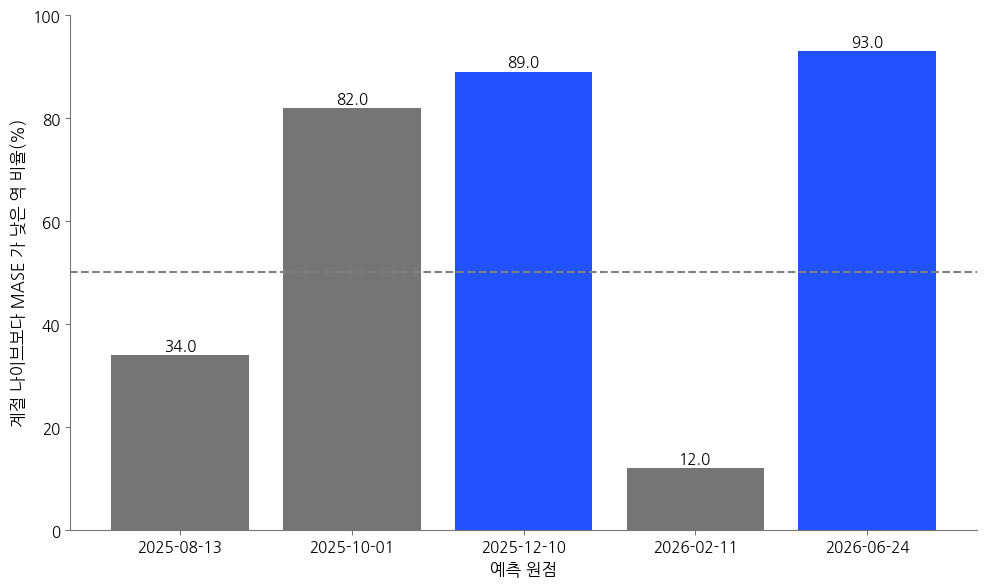

In [4]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 시킬 일은 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 예시 프롬프트도 따옴표 안에 붙여 넣어야 채점됩니다
PROMPT = """
미션 1 준비 셀이 만든 이름(MAT, DATES, STATIONS, ORIGINS, PLAIN_ORIGINS, HOL_ORIGINS, H, CTX, QS, SEED, DEVICE, PIPE, origin_ctx, score, mase_by_station, SN_ST, COL, FIG_W)만 쓰고, PIPE 를 포함해 이 이름들을 다시 만들거나 덮어쓰지 마. 시드는 SEED(0)로 고정해.

1. ORIGINS 의 원점 5개마다 반복해.
   - c = origin_ctx(origin) 으로 o, hist, test, qden 을 받아.
   - 컨텍스트는 원점 전날까지의 마지막 CTX(512)일만 써. 날짜는 DATES[o-CTX:o], 승차는 MAT[:, o-CTX:o] (hist 의 마지막 512열과 같음).
   - 입력 표는 롱 포맷 세 열 item_id · timestamp · target 으로 만들어. item_id 는 역 이름이 아니라 MAT 행 번호 0~99 정수로 둬서 역 순서가 STATIONS 와 같게 해. 100개 역 × 512일 = 51,200행이야.
   - PIPE.predict_df(입력 표, prediction_length=H, quantile_levels=QS, id_column="item_id", timestamp_column="timestamp", target="target") 로 7일을 한 번에 예측해.
   - 출력 표를 item_id, timestamp 순으로 정렬하고 "0.5" 열을 pivot 해서 (100개 역 × 7일) 배열 pred 로 만들어. 행 순서가 item_id 0~99 인지 확인해.
   - score(test, pred, qden)["mase"] 로 원점의 평균 MASE 를, mase_by_station(test, pred, qden) 으로 역별 MASE 100개를 저장해.
   - 역별 MASE 를 같은 원점의 SN_ST[origin] 과 역끼리(같은 인덱스끼리) 비교해서, Chronos-2 쪽이 더 작은 역의 비율(%)을 원점마다 저장해.

2. 아래 두 줄을 이 이름 그대로 출력해.
   - 공휴일 없는 두 주 제로샷 평균 MASE = (PLAIN_ORIGINS 두 원점의 평균 MASE 를 평균, 소수 셋째 자리)
   - 공휴일 없는 두 주에서 계절 나이브보다 MASE 가 낮은 역 비율 = (PLAIN_ORIGINS 두 원점의 역별 MASE 200개 가운데 Chronos-2 가 SN_ST 보다 작은 비율, 단위 %, 소수 첫째 자리) %

3. 그래프 한 장: 원점 5개의 "계절 나이브보다 MASE 가 낮은 역 비율" 막대그래프를 그려. 가로축 이름은 「예측 원점」, 세로축 이름은 「계절 나이브보다 MASE 가 낮은 역 비율(%)」, 세로축 범위는 0~100 으로 해. PLAIN_ORIGINS 원점과 HOL_ORIGINS 원점은 COL 의 색으로 구분하고, 50% 에 점선을 긋고, 막대 위에 비율 값을 적어. 그림 가로 크기는 FIG_W 를 써.
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(SEED)

results = {}

for origin in ORIGINS:
    c = origin_ctx(origin)
    o, hist, test, qden = c["o"], c["hist"], c["test"], c["qden"]

    n_stations = MAT.shape[0]
    dates = DATES[o - CTX:o]
    item_ids = np.repeat(np.arange(n_stations), CTX)
    timestamps = np.tile(dates, n_stations)
    targets = MAT[:, o - CTX:o].reshape(-1)
    df_in = pd.DataFrame({"item_id": item_ids, "timestamp": timestamps, "target": targets})

    pred_df = PIPE.predict_df(
        df_in,
        prediction_length=H,
        quantile_levels=QS,
        id_column="item_id",
        timestamp_column="timestamp",
        target="target",
    )
    pred_df = pred_df.sort_values(["item_id", "timestamp"])
    pred = (
        pred_df.pivot(index="item_id", columns="timestamp", values="0.5")
        .loc[np.arange(n_stations)]
        .values
    )

    mase_origin = score(test, pred, qden)["mase"]
    station_mase = mase_by_station(test, pred, qden)
    beat_pct = (station_mase < SN_ST[origin]).mean() * 100

    results[origin] = {
        "mase": mase_origin,
        "station_mase": station_mase,
        "beat_pct": beat_pct,
    }

공휴일없는두주_평균_MASE = round(
    np.mean([results[o]["mase"] for o in PLAIN_ORIGINS]), 3
)

plain_chronos = np.concatenate([results[o]["station_mase"] for o in PLAIN_ORIGINS])
plain_snst = np.concatenate([SN_ST[o] for o in PLAIN_ORIGINS])
공휴일없는두주_역비율 = round((plain_chronos < plain_snst).mean() * 100, 1)

print(f"공휴일 없는 두 주 제로샷 평균 MASE = {공휴일없는두주_평균_MASE}")
print(f"공휴일 없는 두 주에서 계절 나이브보다 MASE 가 낮은 역 비율 = {공휴일없는두주_역비율}%")

fig, ax = plt.subplots(figsize=(FIG_W, FIG_W * 0.6))
colors = [COL['파랑'] if o in PLAIN_ORIGINS else COL['회색'] for o in ORIGINS]
bars = ax.bar([str(o) for o in ORIGINS], [results[o]["beat_pct"] for o in ORIGINS], color=colors)
ax.axhline(50, linestyle="--", color="gray")
ax.set_xlabel("예측 원점")
ax.set_ylabel("계절 나이브보다 MASE 가 낮은 역 비율(%)")
ax.set_ylim(0, 100)
for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h + 1, f"{h:.1f}", ha="center")
plt.show()

## 미션 2 — 원점 전날까지의 입력으로 다시 채점하기

미션 1 과 같은 Chronos-2 제로샷인데, 전임 담당자는 원점 5개 평균 MASE 를 1.485 로 보고했습니다. 이론 평가표의 Chronos-2 제로샷 원점 5개 평균(7일을 한 번에 예측) 1.766 보다 낮은 값입니다. 전임 담당자가 원점 5개 평균으로 보고했으므로 같은 평균으로 비교합니다.

미션 1 과 같은 순서로 합니다. 다만 「PROMPT 셀」을 먼저 그대로 ▶ 해 전임 담당자 코드의 채점 결과부터 봅니다.

**이 미션의 질문**: 원점 뒤 실측이 입력에 있었는지 어떻게 확인하고, 고치면 보고한 값과 얼마나 달라질까요?

**이 미션은 함정입니다.** 전임 담당자 코드는 7일을 하루씩 예측하며 입력의 끝을 예측할 날의 전날로 옮깁니다. 원점 5개 × 7일 = 35번을 하루씩 예측해 CPU 로는 몇 분 걸립니다.

#### 고칠 것

굵은 이름은 채점이 찾으니 글자 그대로 씁니다.

1. **7일 뒤 예측의 입력에 있는 원점 뒤 실측 일수**: 단위 일 · 정수. 7일을 한 번에 예측하도록 고친 코드에서 7일 뒤 예측의 입력 512일 가운데 날짜가 원점 당일 이후인 날의 개수입니다. 제대로 고쳤다면 0 이 나옵니다. 7일 뒤 예측은 채점 7일째(원점 2026-06-24 면 6월 30일)의 예측입니다. 원점 5개 가운데 가장 큰 값을 적습니다
2. **보고표 평균과의 차이**: 소수 셋째 자리. 7일을 한 번에 예측한 원점 5개 평균 MASE 에서 `REPORTED` 다섯 값의 평균을 뺀 값입니다
3. **그래프 한 장**: 종류는 자유이고 가로축 이름 「예측 원점」, 세로축 이름 「MASE」를 답니다. 권장은 원점마다 보고표 막대와 한 번에 예측한 막대를 나란히 둔 막대그래프입니다

전임 담당자 출력의 세 문구 「제로샷 평균 MASE」·「판단 :」·「운영 가능」은 새로 쓴 행에도 남기지 않습니다. 고친 평균은 「7일을 한 번에 예측한 원점 5개 평균 MASE」라는 이름으로 한 행 함께 출력합니다(채점은 보지 않습니다). 이름에 「제로샷 평균 MASE」가 이어 붙어 있으면 채점은 그 줄을 전임 담당자가 남긴 줄로 보고 통과시키지 않습니다. 「Chronos-2 제로샷 평균 MASE = 1.766」 이 그런 예입니다.

**통과 기준**: 1·2번 값이 「이름 = 값」 한 행씩 있고 기준 범위 안이며, 세 문구(「제로샷 평균 MASE」·「판단 :」·「운영 가능」)가 출력에 없어야 합니다. 그래프는 가로축·세로축 이름이 있으면 통과입니다.

| 원점 2026-06-24 에서 예측할 날 | 며칠 뒤 예측(원점 전날 기준) | 7일을 한 번에 예측할 때 입력 끝 | 날마다 다시 예측할 때 입력 끝 |
|---|---|---|---|
| 6월 24일(수) | 1일 뒤 | 6월 23일 | 6월 23일(두 방식 같음) |
| 6월 27일(토) | 4일 뒤 | 6월 23일 | 6월 26일(원점 뒤 실측 3일 포함) |
| 6월 30일(화) | 7일 뒤 | 6월 23일 | 6월 29일(원점 뒤 실측 6일 포함) |

**쓸 수 있는 것**: 「미션 2 준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 |
|---|---|
| `MAT` · `DATES` · `STATIONS` · `ORIGINS` · `PLAIN_ORIGINS` · `HOL_ORIGINS` · `H` · `CTX` · `QS` · `SEED` · `DEVICE` · `PIPE` · `origin_ctx(origin)` · `score(y, pred, qden)` | 미션 1 과 같은 이름과 뜻 |
| `REPORTED` | 전임 담당자의 보고표. 원점 날짜 → 날마다 다시 예측해 구한 MASE |

#### 프롬프트에 넣을 것(힌트)

- **고칠 곳**: 입력의 끝을 정하는 줄과 예측 길이를 무엇으로 바꿀지, 하루씩 도는 루프를 없앤다는 것을 적습니다.
- **확인할 값**: 원점마다 7일 뒤 예측에 쓴 입력의 마지막 날과, 그 입력 가운데 날짜가 원점 당일 이후인 날의 개수를 한 행씩 출력하라고 적습니다.
- **출력·그래프**: 값 두 개의 이름·자릿수와 빼는 순서, 세 문구를 출력에서 지우기를 적습니다. 그래프에는 가로축·세로축 이름을 달라고 적습니다.

#### 틀린 곳 찾기

> **[예측] AI 코드 표시선(`# --- 여기부터 AI 코드 ---`) 아래 전임 담당자 코드는 오류 없이 실행되는데 답이 틀렸습니다. 코드의 `h` 는 원점부터 며칠째 날을 예측하는지 나타내는 수(0～6)입니다. 틀린 곳은 어디일까요?**
>
> 1. `end = o + h`: `h` 가 1 이상이면 원점부터 예측할 날의 전날까지의 실측이 입력에 들어간다
> 2. `prediction_length=1`: 하루씩 예측하면 한 번에 예측할 때보다 오래 걸린다
> 3. `context_length=CTX`: 512일이 너무 길어 오래된 자료가 예측을 흐린다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

<details class="lms-extra"><summary>배경 — 하루 뒤 예측과 네 시점 뒤 예측</summary>

두 그림 모두 가로축은 시각이고, 가로줄 하나가 예측 한 번입니다. 파란 점은 예측에 쓴 관측, 주황 점은 그 줄에서 채점하는 시각, 회색 점은 쓰지 않은 시각입니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/cv1-1.png" alt="분할마다 한 줄씩, 파란 점 바로 뒤에 주황 점 하나가 있고 아래 줄로 갈수록 파란 점이 하나씩 늘어나는 그림" width="640" height="300"/>
<p align="center"><em>▲ 하루 뒤 예측. 주황 점이 늘 파란 점 바로 다음 시각에 있다. 아래 줄로 갈수록 파란 점이 하나씩 늘어나는 것은 앞 줄에서 채점한 시각의 실측을 받아 다음 예측에 썼다는 뜻이고, 전임 담당자 코드의 7일이 모두 이 모양이다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3rd ed., §5.10)</em></p>

<img src="https://otexts.com/fpp3/fpp_files/figure-html/cv4-1.png" alt="분할마다 한 줄씩, 파란 점과 주황 점 사이에 회색 점 세 개가 있는 그림" width="640" height="300"/>
<p align="center"><em>▲ 네 시점 뒤 예측. 파란 점과 주황 점 사이의 회색 세 점은 예측하는 시점에 아직 실측이 없는 시각이다. 아래 줄로 갈수록 파란 점이 늘어나는 것은 첫째 그림과 같은 뜻이다. 원점에서 7일을 한 번에 예측하면 4일 뒤 예측이 이 모양이고, 7일 뒤는 회색 점이 여섯 개다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3rd ed., §5.10)</em></p>

</details>

<details class="lms-extra"><summary>자세히 — AI 튜터에 맡길 일과 내가 확인할 일</summary>

| AI 튜터에 맡길 일 | 내가 확인할 일 |
|---|---|
| 7일을 한 번에 예측하도록 바꾸는 코드 | 원점마다 입력의 **마지막 날이 원점 전날**인가 |
| 원점별 보고표 값과 고친 값을 나란히 출력 | 7일 뒤 예측의 입력에 있는 **원점 뒤 실측이 0일**인가 |
| 옛 이름 바꾸기, 막대그래프 | 새로 쓴 행까지 **세 문구(「제로샷 평균 MASE」·「판단 :」·「운영 가능」)가 출력에 없는가**, 막대가 원점마다 둘씩 모두 **10개**인가 |

</details>

<details class="lms-extra"><summary>예상 확인 — 「PROMPT 셀」을 그대로 실행한 뒤 펼칩니다</summary>

답은 첫째 보기입니다. `h`(원점부터 며칠째, 0～6)가 1 이상이면 `end = o + h` 가 입력의 끝을 원점 뒤로 옮겨, 원점 뒤 실측 h일을 입력에 넣습니다. 원점 2026-06-24 에서 6월 30일(`h = 6`)을 예측하면 입력이 6월 29일에서 끝나, 6월 24～29일의 실측 6일이 입력에 있습니다.

- 「`prediction_length=1`」: 이 줄도 고치지만 틀린 까닭은 아닙니다. `end` 를 `o` 로 고정한 뒤 `prediction_length` 를 7 로 함께 바꾸는 줄입니다. 하루씩 예측하면 오래 걸리는 것은 맞지만, 보고한 MASE 를 1.485 로 낮춘 것은 걸린 시간이 아니라 입력에 있는 원점 뒤 실측입니다.
- 「`context_length=CTX`」: 미션 1 과 같은 512일이라 고칠 곳이 아닙니다. 이론 평가표의 1.766 도 같은 512일로 낸 값입니다.

</details>

In [5]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다
import os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

RAW_URL = "https://github.com/studio-js/seoul-subway-ridership/raw/main/data/seoul_subway_daily_2015_2026.parquet"
CACHE = "seoul_subway_daily.parquet"          # 한 번 받아 두면 다시 받지 않습니다
if not os.path.exists(CACHE):
    pd.read_parquet(RAW_URL).to_parquet(CACHE)

# 첫날과 같은 손질: 역 이름의 괄호 별칭을 떼고 9호선 이름을 맞춘 뒤 (날짜, 호선, 역) 으로 합칩니다
_raw = pd.read_parquet(CACHE)
_raw["date"] = pd.to_datetime(_raw["date"])
_raw["station"] = _raw["station"].astype(str).str.replace(r"\(.*\)$", "", regex=True)
_raw["line"] = _raw["line"].astype(str).replace({"9호선2단계": "9호선(2~3단계)",
                                                "9호선2~3단계": "9호선(2~3단계)"})
_clean = _raw.groupby(["date", "line", "station"], as_index=False,
                      observed=True)[["board", "alight"]].sum()
_span = _clean.groupby(["line", "station"])["date"].agg(["min", "max", "count"])
_full = _span[(_span["min"] <= pd.Timestamp("2015-01-01")) &            # 기록이 끊기지 않은 역만 남긴 뒤
              (_span["max"] >= pd.Timestamp("2026-06-30")) & (_span["count"] >= 4190)]
_top = (_clean[_clean["date"] <= pd.Timestamp("2024-12-31")]             # 2024년까지 평균 승차 상위 100개 역
        .groupby(["line", "station"])["board"].mean()
        .loc[_full.index].sort_values(ascending=False).index[:100])
_wide = _clean.pivot_table(index=["line", "station"], columns="date", values="board").loc[_top]

MAT = _wide.to_numpy(dtype=float)             # 100개 역 x 4,199일 승차 (명)
DATES = pd.DatetimeIndex(_wide.columns)       # 표 열의 날짜
STATIONS = [f"{_line} {_name}" for _line, _name in _wide.index]   # 표 행의 역 이름

ORIGINS = ["2025-08-13", "2025-10-01", "2025-12-10", "2026-02-11", "2026-06-24"]   # 예측 원점 5개 (수요일)
PLAIN_ORIGINS = ["2025-12-10", "2026-06-24"]                                       # 공휴일 없는 두 주
HOL_ORIGINS = ["2025-08-13", "2025-10-01", "2026-02-11"]                           # 공휴일 있는 세 주
H, CTX = 7, 512                               # 채점 7일 · 컨텍스트 512일
QS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # Chronos-2 가 내는 분위수 아홉 개 (점 예측은 0.5)
SEED = 0                                      # 시드
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # 설치 셀과 같은 규칙, 이 셀만 실행해도 정해집니다
torch.backends.cuda.matmul.allow_tf32 = False            # fp32 로 계산합니다


def origin_ctx(origin):
    """원점 하나의 자료 — 원점의 열 번호(o), 원점 전날까지의 100개 역(hist), 채점 7일(test, 명), 역별 MASE 분모(qden)"""
    o = int(DATES.get_loc(pd.Timestamp(origin)))
    hist = MAT[:, :o]
    qden = np.nanmean(np.abs(hist[:, 7:] - hist[:, :-7]), axis=1)   # 원점 전날까지로 계산한 분모
    return dict(o=o, hist=hist, test=MAT[:, o:o + H], qden=qden)


def score(y, pred, qden):
    """MASE(역마다 분모로 나눈 절대 오차의 평균)와 RMSE(명)를 사전으로 돌려줍니다"""
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    q = np.asarray(qden, dtype=float).reshape(-1, 1)
    return dict(mase=float(np.mean(np.abs(y - pred) / q)),
                rmse=float(np.sqrt(np.mean((y - pred) ** 2))))


# 전임 담당자가 남긴 보고표. 원점마다 7일을 하루씩 예측하며, 예측할 날의 전날 실측까지
#  입력에 넣어 채점한 제로샷 MASE 입니다. 아래 「PROMPT 셀」의 전임 담당자 코드를 그대로 실행하면
#  이 값이 다시 나옵니다. 고친 코드는 이 값을 쓰고, 하루씩 도는 계산을 다시 실행하지 않습니다.
_g, _o = STATIONS.index("2호선 강남"), int(DATES.get_loc(pd.Timestamp("2026-06-24")))
assert tuple(MAT[_g, _o:_o + 3]) == (94303, 94077, 98456)             # 자료 확인 — 강남 6월 24~26일 실측
REPORTED = {"2025-08-13": 1.078524, "2025-10-01": 3.519137, "2025-12-10": 0.269499,
            "2026-02-11": 2.307275, "2026-06-24": 0.248111}

# Chronos-2 를 DEVICE 에 올립니다. 맨 위 설치 셀이 내려받아 둔 가중치를 읽습니다
from chronos import BaseChronosPipeline
_t0 = time.perf_counter()
PIPE = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE, torch_dtype=torch.float32)
_load_sec = time.perf_counter() - _t0

print(f"행렬 : {MAT.shape[0]}개 역 x {MAT.shape[1]:,}일 · {DATES[0].date()} ~ {DATES[-1].date()}")
print("원점 5개 :", " · ".join(ORIGINS), f"— 원점마다 원점 전날까지의 {CTX}일을 컨텍스트로 씁니다")
print(f"Chronos-2 : amazon/chronos-2 · fp32 · DEVICE {DEVICE} · 불러오기 {_load_sec:.1f}초 · 학습 없음")
print("전임 담당자의 보고표 (제로샷 MASE, 날마다 다시 예측해 계산) :",
      " · ".join(f"{k} {v:.3f}" for k, v in REPORTED.items()),
      f"(평균 {np.mean(list(REPORTED.values())):.3f})")
print("쓸 수 있는 이름 : MAT · DATES · STATIONS · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · H · CTX · QS · SEED"
      " · DEVICE · PIPE · origin_ctx(origin) · score(y, pred, qden) · REPORTED")

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 945.16it/s]
행렬 : 100개 역 x 4,199일 · 2015-01-01 ~ 2026-06-30
원점 5개 : 2025-08-13 · 2025-10-01 · 2025-12-10 · 2026-02-11 · 2026-06-24 — 원점마다 원점 전날까지의 512일을 컨텍스트로 씁니다
Chronos-2 : amazon/chronos-2 · fp32 · DEVICE cuda · 불러오기 1.2초 · 학습 없음
전임 담당자의 보고표 (제로샷 MASE, 날마다 다시 예측해 계산) : 2025-08-13 1.079 · 2025-10-01 3.519 · 2025-12-10 0.269 · 2026-02-11 2.307 · 2026-06-24 0.248 (평균 1.485)
쓸 수 있는 이름 : MAT · DATES · STATIONS · ORIGINS · PLAIN_ORIGINS · HOL_ORIGINS · H · CTX · QS · SEED · DEVICE · PIPE · origin_ctx(origin) · score(y, pred, qden) · REPORTED


원점 2025-08-13 · 입력 마지막 날 2025-08-12 00:00:00 · 원점 뒤 실측 일수 0
원점 2025-10-01 · 입력 마지막 날 2025-09-30 00:00:00 · 원점 뒤 실측 일수 0
원점 2025-12-10 · 입력 마지막 날 2025-12-09 00:00:00 · 원점 뒤 실측 일수 0
원점 2026-02-11 · 입력 마지막 날 2026-02-10 00:00:00 · 원점 뒤 실측 일수 0
원점 2026-06-24 · 입력 마지막 날 2026-06-23 00:00:00 · 원점 뒤 실측 일수 0
7일 뒤 예측의 입력에 있는 원점 뒤 실측 일수 = 0
보고표 평균과의 차이 = 0.281
7일을 한 번에 예측한 원점 5개 평균 MASE = 1.766

──────────────────────────────────────────────────────
◼ 미션 2 채점 결과
✅ 7일 뒤 예측의 입력에 있는 원점 뒤 실측 일수 — 출력에서 찾은 값: 0
   ⓘ 단위 「일」 도 값과 함께 출력하면 보고서에 그대로 옮길 수 있습니다
✅ 보고표 평균과의 차이 — 출력에서 찾은 값: 0.281
✅ 그래프 — 그림이 있고 가로축·세로축 이름이 있습니다
──────────────────────────────────────────────────────


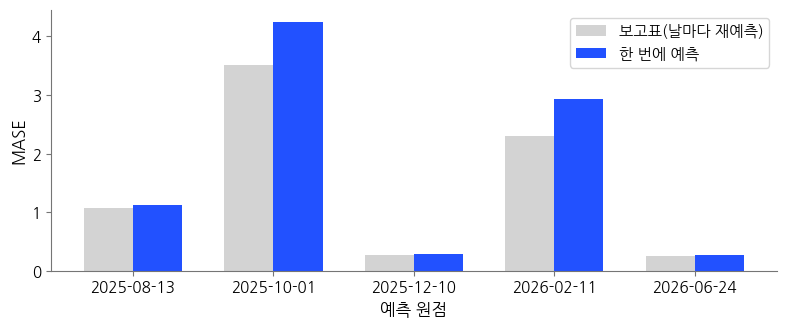

In [6]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다 — 아래는 전임 담당자가 남긴 코드라 돌아가지만 답이 틀렸습니다.   # [heavy]
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 튜터가 AI 코드 표시선 아래를 다시 씁니다.
# 고칠 지시는 AI 튜터 대화창이 아니라 아래 따옴표 안에 적습니다. 대화창에만 쓰면 진단은 나오지만 완성본 풀이가 열리지 않습니다
PROMPT = """
전임 담당자 코드는 원점마다 7일을 하루씩 루프로 예측하면서 입력의 끝을 예측할 날의 전날로 옮겨서, 원점 뒤 실측이 입력에 들어간다. 이걸 고쳐 줘.

미션 2 준비 셀이 만든 이름(MAT, DATES, STATIONS, ORIGINS, PLAIN_ORIGINS, HOL_ORIGINS, H, CTX, QS, SEED, DEVICE, PIPE, origin_ctx, score, REPORTED)만 쓰고, PIPE 를 포함해 이 이름들을 다시 만들거나 덮어쓰지 마. 시드는 SEED(0)로 고정해.

1. 고칠 곳
   - 하루씩 도는 루프(7번 반복)를 없애.
   - 입력의 끝을 정하는 줄을 예측할 날의 전날이 아니라 원점 전날로 고정해. 원점마다 c = origin_ctx(origin) 의 o 를 써서 입력은 날짜 DATES[o-CTX:o], 승차 MAT[:, o-CTX:o] 의 512일만 쓴다.
   - 입력 표는 롱 포맷 item_id(MAT 행 번호 0~99 정수) · timestamp · target 세 열로 만들어.
   - 예측 길이를 1 이 아니라 prediction_length=H(7)로 바꿔서 PIPE.predict_df(입력 표, prediction_length=H, quantile_levels=QS, id_column="item_id", timestamp_column="timestamp", target="target") 를 원점마다 한 번만 호출해.
   - 출력 표를 item_id, timestamp 순으로 정렬하고 "0.5" 열을 (100개 역 × 7일) 배열로 pivot 해서 score(c["test"], pred, c["qden"])["mase"] 로 원점의 MASE 를 구해.

2. 확인할 값: 원점마다 한 행씩 출력해.
   - 원점 날짜, 7일 뒤 예측(채점 7일째)에 쓴 입력의 마지막 날, 그 입력 512일 가운데 날짜가 원점 당일 이후(>= 원점)인 날의 개수.
   - 7일을 한 번에 예측하므로 7일 뒤 예측의 입력도 위 512일과 같다.

3. 출력: 아래 세 줄을 이 이름 그대로 출력해.
   - 7일 뒤 예측의 입력에 있는 원점 뒤 실측 일수 = (원점 5개 가운데 가장 큰 개수, 정수)
   - 보고표 평균과의 차이 = (7일을 한 번에 예측한 원점 5개 평균 MASE − REPORTED 다섯 값의 평균, 소수 셋째 자리)
   - 7일을 한 번에 예측한 원점 5개 평균 MASE = (소수 셋째 자리)
   전임 담당자 코드가 출력하던 「제로샷 평균 MASE」, 「판단 :」, 「운영 가능」 세 문구는 어떤 행에도 남기지 말고 그 print 문을 지워. 새로 쓰는 행 이름에도 「제로샷 평균 MASE」라는 글자가 이어 붙지 않게 해.

4. 그래프 한 장: 원점 5개마다 REPORTED 값(날마다 다시 예측) 막대와 7일을 한 번에 예측한 MASE 막대를 나란히 그린 막대그래프. 가로축 이름은 「예측 원점」, 세로축 이름은 「MASE」로 달고, 범례에 두 방식을 표시해.
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

n_st = len(STATIONS)
mase_onepass = {}
leak_counts = []

for origin in ORIGINS:
    c = origin_ctx(origin)
    o = c["o"]
    origin_date = DATES[o]

    ctx_dates = DATES[o - CTX:o]
    long_df = pd.DataFrame({
        "item_id": np.repeat(np.arange(n_st), CTX),
        "timestamp": np.tile(ctx_dates.values, n_st),
        "target": MAT[:, o - CTX:o].ravel(),
    })

    torch.manual_seed(SEED)
    fc = PIPE.predict_df(
        long_df,
        prediction_length=H,
        quantile_levels=QS,
        id_column="item_id",
        timestamp_column="timestamp",
        target="target",
    )
    fc = fc.sort_values(["item_id", "timestamp"])
    pred = fc.pivot(index="item_id", columns="timestamp", values="0.5").loc[np.arange(n_st)].values

    mase_onepass[origin] = score(c["test"], pred, c["qden"])["mase"]

    last_input_date = ctx_dates.max()
    leak = int((ctx_dates >= origin_date).sum())
    leak_counts.append(leak)
    print(f"원점 {origin} · 입력 마지막 날 {last_input_date} · 원점 뒤 실측 일수 {leak}")

원점뒤실측일수_최대 = int(max(leak_counts))
onepass_mean = np.mean(list(mase_onepass.values()))
reported_mean = np.mean(list(REPORTED.values()))
보고표평균과의차이 = round(onepass_mean - reported_mean, 3)

print(f"7일 뒤 예측의 입력에 있는 원점 뒤 실측 일수 = {원점뒤실측일수_최대}")
print(f"보고표 평균과의 차이 = {보고표평균과의차이}")
print(f"7일을 한 번에 예측한 원점 5개 평균 MASE = {round(onepass_mean, 3)}")

fig, ax = plt.subplots(figsize=(8, 3.4))
x = np.arange(len(ORIGINS))
width = 0.35
ax.bar(x - width / 2, [REPORTED[o] for o in ORIGINS], width, label="보고표(날마다 재예측)", color="lightgray")
ax.bar(x + width / 2, [mase_onepass[o] for o in ORIGINS], width, label="한 번에 예측", color="#2251FF")
ax.set_xticks(x)
ax.set_xticklabels(ORIGINS)
ax.set_xlabel("예측 원점")
ax.set_ylabel("MASE")
ax.legend()
plt.show()

## 오늘의 결론

<div class="lms-summary">

**정리**

- 공휴일 없는 두 주: Chronos-2 제로샷 평균 MASE 0.271, 계절 나이브 0.445 입니다. 제로샷이 계절 나이브보다 MASE 가 낮은 역은 원점 2025-12-10 에서 89개, 2026-06-24 에서 93개입니다
- 공휴일 있는 세 주: 평균 MASE 2.763 으로 계절 나이브 2.767 과 거의 같습니다. 평일 공휴일 6일에는 100개 역 합으로 실제의 2.14배를 예측했습니다
- 전임 담당자의 원점 5개 평균 MASE 1.485 는 원점 뒤 실측을 입력에 쓴 값이라 평가표에 적지 않습니다(7일을 한 번에 예측한 값 1.766)
- 할 일: `PIPE.predict_df` 에 역·날짜·승차 세 열과 원점 전날까지 512일을 전달하고 `"0.5"` 열로 채점합니다. 평일 공휴일이 있는 주의 공휴일 날 인력은 이 예측으로 정하지 않습니다

Chronos-2 제로샷은 공휴일 없는 주의 역별 인력 예측 후보로 올리고, 평일 공휴일이 있는 주에는 그대로 쓰지 않습니다.

</div>

> **[과제] 실습 제출 — Chronos-2 제로샷의 MASE 와 원점 전날까지의 입력으로 다시 채점하기**
>
> 미션 1·2 의 「PROMPT 셀」이 채점을 통과한 상태로 노트북을 제출합니다. PROMPT 는 내가 쓴 그대로 둡니다.
>
> 마감: 2026-10-20T23:59+09:00
>
> **평가 기준**
>
> | 기준 | 이렇게 하면 충족 | 배점 |
> | --- | --- | --- |
> | 미션 1 | 채점을 통과했고 PROMPT 에 만들 것이 내 말로 적혀 있다 | 50 |
> | 미션 2 | 채점을 통과했고 PROMPT 에 고칠 것이 내 말로 적혀 있다 | 50 |
>
> 제출은 LMS 레슨 화면의 과제 카드에서 GitHub 링크로 합니다(이 파일에 적으면 제출되지 않습니다).

<div style="background:#F2F2F2;color:#000000;padding:28px;border-radius:12px;border:1px solid #E6E6E6;margin-top:16px;border-left:4px solid #051C2C">
<h2 style="color:#000000;margin:0 0 8px 0">수고했습니다 — 딥러닝 시계열 둘째 날 완료</h2>
<div style="color:#656565">Chronos-2 제로샷을 예측 원점 5개에 불러 평가표에 MASE 를 적고, 원점 뒤 실측을 입력에 쓴 채점을 7일을 한 번에 예측한 채점으로 고쳤습니다.</div>
</div>